Perbandingan penggunaan aplikasi baca webtoon dan karyakarsa di google play store berdasarkan analisis review pengguna.

In [ ]:
!pip install google-play-scraper

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 1.9 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import re
import string
from google_play_scraper import reviews, Sort
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import LatentDirichletAllocation
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from collections import Counter

In [ ]:
#Scraping data
def scrape_reviews(app_id, app_name, count=5000):
    result, _ = reviews(
        app_id,
        lang='id',
        country='id',
        sort=Sort.MOST_RELEVANT,
        count=count,
        filter_score_with=None
    )
    if not result:
        df = pd.DataFrame(columns=['content', 'score', 'at'])
    else:
        df = pd.DataFrame(result)
        required_cols = ['content', 'score', 'at']
        for col in required_cols:
            if col not in df.columns:
                df[col] = None
        df = df[['content', 'score', 'at']]
        df.rename(columns={'content':'text'}, inplace=True)
        df['app'] = app_name
    return df

df_webtoon = scrape_reviews('com.naver.linewebtoon', 'Webtoon', 5000)
df_karyakarsa = scrape_reviews('com.karyakarsa', 'Karyakarsa', 5000)

# Gabungkan dataset
df = pd.concat([df_webtoon, df_karyakarsa], ignore_index=True)

In [ ]:
import pandas as pd
from google_play_scraper import reviews, Sort

# ================================
# Fungsi Scraping Review
# ================================
def scrape_reviews(app_id, app_name, count=10000):
    result, _ = reviews(
        app_id,
        lang='id',
        country='id',
        sort=Sort.MOST_RELEVANT,
        count=count,
        filter_score_with=None
    )

    if not result:
        df = pd.DataFrame(columns=['ulasan', 'rating', 'at', 'app'])
    else:
        df = pd.DataFrame(result)
        df = df[['content', 'score', 'at']]
        df.rename(columns={
            'content': 'ulasan',
            'score': 'rating'
        }, inplace=True)
        df['app'] = app_name

    return df


# ================================
# Scraping per Aplikasi
# ================================
df_webtoon = scrape_reviews(
    'com.naver.linewebtoon',
    'Webtoon',
    10000
)

df_karyakarsa = scrape_reviews(
    'com.karyakarsa',
    'Karyakarsa',
    10000
)

# ================================
# Simpan CSV Terpisah
# ================================
df_webtoon.to_csv(
    'dataset_ulasan_webtoon.csv',
    index=False,
    encoding='utf-8-sig'
)

df_karyakarsa.to_csv(
    'dataset_ulasan_karyakarsa.csv',
    index=False,
    encoding='utf-8-sig'
)

In [ ]:
# Definisikan daftar kata kunci untuk setiap kategori
keywords_terlaris = ['terlaris', 'populer', 'banyak dibaca', 'favorit', 'top', 'hits']
keywords_rating_tinggi = ['bintang 5', 'bagus sekali', 'rating tinggi', 'paling bagus', 'rekomendasi']
keywords_premium = ['premium', 'berbayar', 'koin', 'langganan', 'akses']

def filter_reviews(df, keywords):
    pattern = '|'.join(keywords)
    return df[df['text'].str.contains(pattern, case=False, na=False)]

# Filter ulasan dari semua data
df_terlaris = filter_reviews(df, keywords_terlaris)
df_rating_tinggi = filter_reviews(df, keywords_rating_tinggi)
df_premium = filter_reviews(df, keywords_premium)


print("===== Terlaris ====")
print(df_terlaris[['app', 'text', 'score']].head(10))

print("\n===== Rating Tinggi ====")
print(df_rating_tinggi[['app', 'text', 'score']].head(10))

print("\n===== Premium ====")
print(df_premium[['app', 'text', 'score']].head(10))


===== Terlaris ====
         app                                               text  score
1    Webtoon  Bintang 5!! tapi anehnya, kalau aku mau buka e...      4
10   Webtoon  kenapa ya belakangan ini gak bisa mutar iklan ...      2
24   Webtoon  udah bagus, cuma kurang puas karna tombol like...      2
38   Webtoon  aku udah lama setia sama nih apk, apk nya muda...      4
71   Webtoon  sebagai pengguna dan pembaca webtoon dari lama...      3
93   Webtoon  aku suka si sama apk ini. Tapi gatau kenapa pa...      3
104  Webtoon  woi,ini gimana sih. masa akhir" ini gk bisa no...      1
112  Webtoon  plis developer ini aplikasi terfavorit ku mula...      1
125  Webtoon  tolong fitur pencariannya kembalikan seperti y...      3
152  Webtoon  tolong webtoon, ini kenapa saya susah untuk lo...      3

===== Rating Tinggi ====
         app                                               text  score
1    Webtoon  Bintang 5!! tapi anehnya, kalau aku mau buka e...      4
117  Webtoon  Sebenarnya saya s

In [ ]:
# Statistik rating
df['score'].describe()

,score
count,7665.000000
mean,3.424527
std,1.603208
min,1.000000
25%,2.000000
50%,4.000000
75%,5.000000
max,5.000000


In [ ]:
df['app'].value_counts()

,count
app,
Webtoon,5000
Karyakarsa,2665


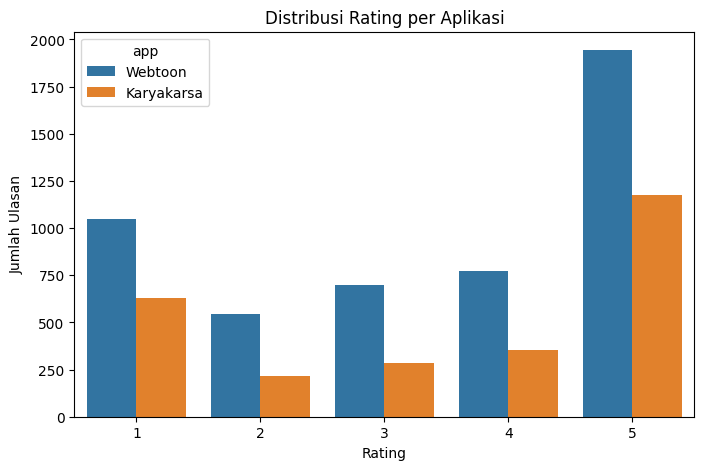

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.countplot(x='score', hue='app', data=df)
plt.title('Distribusi Rating per Aplikasi')
plt.xlabel('Rating')
plt.ylabel('Jumlah Ulasan')
plt.show()

In [ ]:
df['ulasan_length'] = df['text'].apply(lambda x: len(str(x).split()))
df.groupby('app')['ulasan_length'].describe()

,count,mean,std,min,25%,50%,75%,max
app,,,,,,,,
Karyakarsa,2665.0,15.408255,16.513733,1.0,3.0,10.0,21.0,96.0
Webtoon,5000.0,37.874200,20.835249,2.0,21.0,36.0,51.0,130.0


In [ ]:
# Review terpanjang
df.iloc[df['ulasan_length'].idxmax()][['app','text','score']]

# Review terpendek
df.iloc[df['ulasan_length'].idxmin()][['app','text','score']]

,7078
app,Karyakarsa
text,menyenangkan
score,5


In [ ]:
# Total ulasan
total_ulasan = len(df)
print(f"Total ulasan dari kedua APK: {total_ulasan}")

# Jumlah ulasan per aplikasi
total_per_app = df['app'].value_counts()
print("Jumlah ulasan per aplikasi:")
print(total_per_app)

# Total ulasan per rating
total_per_rating = df.groupby(['app','score']).size().reset_index(name='jumlah')
print(total_per_rating)

Total ulasan dari kedua APK: 7665
Jumlah ulasan per aplikasi:
app
Webtoon       5000
Karyakarsa    2665
Name: count, dtype: int64
          app  score  jumlah
0  Karyakarsa      1     630
1  Karyakarsa      2     218
2  Karyakarsa      3     286
3  Karyakarsa      4     353
4  Karyakarsa      5    1178
5     Webtoon      1    1047
6     Webtoon      2     542
7     Webtoon      3     696
8     Webtoon      4     771
9     Webtoon      5    1944


In [ ]:
df['ulasan_lower'] = df['text'].str.lower()

In [ ]:
import re

def clean_text(text):
    text = str(text)
    text = re.sub(r'[^\x00-\x7F]+', ' ', text)  # hapus non-ASCII / emoji
    text = re.sub(r'\d+', ' ', text)            # hapus angka
    text = re.sub(r'[^\w\s]', ' ', text)        # hapus tanda baca
    return text

df['ulasan_clean'] = df['ulasan_lower'].apply(clean_text)


In [ ]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

stop_words = set(stopwords.words('indonesian'))

def remove_stopwords(text):
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return ' '.join(words)

df['ulasan_stopword'] = df['ulasan_clean'].apply(remove_stopwords)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
!pip install Sastrawi
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

factory = StemmerFactory()
stemmer = factory.create_stemmer()

def stemming_text(text):
    return stemmer.stem(text)

df['ulasan_stem'] = df['ulasan_stopword'].apply(stemming_text)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 10.2 MB/s eta 0:00:00


In [ ]:
df.head()

,text,score,at,app,ulasan_length,ulasan_lower,ulasan_clean,ulasan_stopword,ulasan_stem
0,iklan di tengah-tengah atau setiap selesai 1 e...,2,2025-12-09 10:11:11,Webtoon,41,iklan di tengah-tengah atau setiap selesai 1 e...,iklan di tengah tengah atau setiap selesai e...,iklan selesai episode langsung ngarahin aplika...,iklan selesai episode langsung ngarahin aplika...
1,"Bintang 5!! tapi anehnya, kalau aku mau buka e...",4,2025-10-02 13:58:50,Webtoon,76,"bintang 5!! tapi anehnya, kalau aku mau buka e...",bintang tapi anehnya kalau aku mau buka e...,bintang anehnya buka episode iklan berbayar ka...,bintang aneh buka episode iklan bayar kadang g...
2,"bagus bgt, suka sama cerita2 nya, bisa dibaca ...",5,2025-10-07 10:55:55,Webtoon,56,"bagus bgt, suka sama cerita2 nya, bisa dibaca ...",bagus bgt suka sama cerita nya bisa dibaca ...,bagus bgt suka cerita nya dibaca diwaktu santa...,bagus bgt suka cerita nya baca waktu santai si...
3,aplikasinya sangat bagus untuk membaca beberap...,3,2025-12-12 15:32:18,Webtoon,72,aplikasinya sangat bagus untuk membaca beberap...,aplikasinya sangat bagus untuk membaca beberap...,aplikasinya bagus membaca karya artis negara c...,aplikasi bagus baca karya artis negara cuman r...
4,"Gasuka tampilan webtoon yg sekarang, makanya s...",3,2025-11-30 10:48:11,Webtoon,62,"gasuka tampilan webtoon yg sekarang, makanya s...",gasuka tampilan webtoon yg sekarang makanya s...,gasuka tampilan webtoon yg jarang buka gabisa ...,gasuka tampil webtoon yg jarang buka gabisa ya...


/tmp/ipython-input-180811272.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sentimen_count.index, y=sentimen_count.values, palette='viridis')


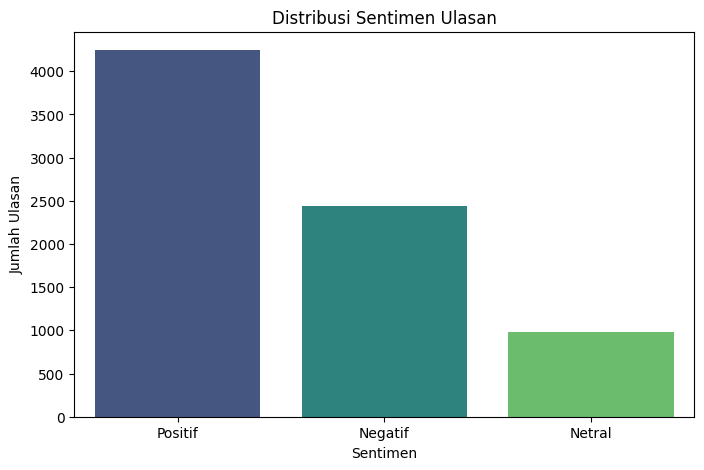

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Tambahkan kolom sentimen berdasarkan rating
def get_sentiment(score):
    if score >= 4:
        return 'Positif'
    elif score == 3:
        return 'Netral'
    else:
        return 'Negatif'

df['sentimen'] = df['score'].apply(get_sentiment)

sentimen_count = df['sentimen'].value_counts()

plt.figure(figsize=(8,5))
sns.barplot(x=sentimen_count.index, y=sentimen_count.values, palette='viridis')
plt.title('Distribusi Sentimen Ulasan')
plt.xlabel('Sentimen')
plt.ylabel('Jumlah Ulasan')
plt.show()

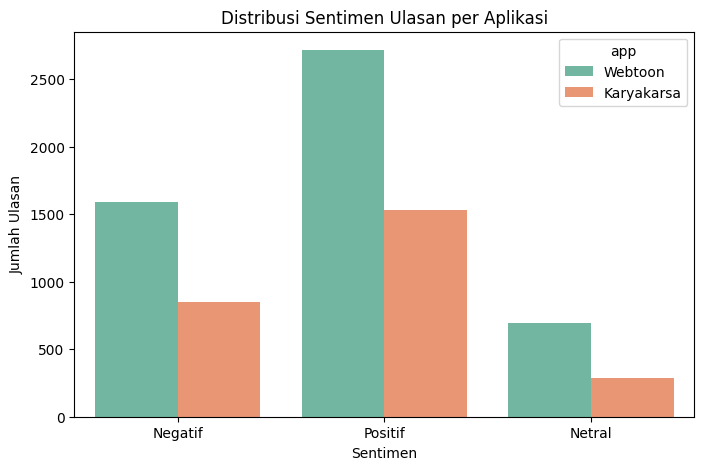

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='sentimen', hue='app', data=df, palette='Set2')
plt.title('Distribusi Sentimen Ulasan per Aplikasi')
plt.xlabel('Sentimen')
plt.ylabel('Jumlah Ulasan')
plt.show()

In [ ]:
# Ambil sampel 20 ulasan dari setiap label
sample_df = df.groupby('sentimen').sample(20, random_state=42)
sample_df[['text', 'score', 'sentimen']]

,text,score,sentimen
5290,Penulis nya pada gak adil. Mereka jual kembali...,1,Negatif
3141,sering bgt malah dialihkan apk shoppee. jadi g...,1,Negatif
1929,Ohh skrg pake koin kalo mau baca?? Pantes load...,1,Negatif
6502,Udah beli koin tapi gak masuk aplikasi scam,1,Negatif
3796,"Knp ya webtoon nya suka eror mulu, awalnya say...",2,Negatif
1361,saran dari gw wahai webtoon yang terhormat 🙏un...,1,Negatif
664,setelah bertahun-tahun saya menggunakan webtoo...,1,Negatif
5509,Koin yang saya beli tidak muncul Tapi uang dir...,1,Negatif
667,Maaf ni webtoon aku lebih suka temanya sebelum...,2,Negatif
5332,"Saya lebih suka versi lama, kakkoin lebih meng...",1,Negatif


In [ ]:
positif_words = ['bagus', 'mantap', 'hebat', 'suka', 'recommended']
negatif_words = ['buruk', 'jelek', 'tidak', 'mengecewakan', 'parah']

def validate_label(row):
    text = row['text'].lower()
    label = row['sentimen']

    if label == 'Positif' and any(word in text for word in negatif_words):
        return 'Perlu Dicek'
    if label == 'Negatif' and any(word in text for word in positif_words):
        return 'Perlu Dicek'
    return 'Valid'

df['label_validasi'] = df.apply(validate_label, axis=1)

In [ ]:
df['label_validasi'].value_counts()

,count
label_validasi,
Valid,6561
Perlu Dicek,1104


In [ ]:
validasi_count = df['label_validasi'].value_counts()
print(validasi_count)

label_validasi
Valid          6561
Perlu Dicek    1104
Name: count, dtype: int64


/tmp/ipython-input-3038145240.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=validasi_count.index, y=validasi_count.values, palette='Set1')


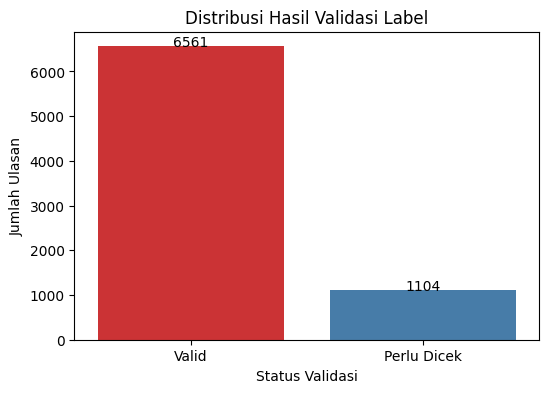

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.barplot(x=validasi_count.index, y=validasi_count.values, palette='Set1')
plt.title('Distribusi Hasil Validasi Label')
plt.xlabel('Status Validasi')
plt.ylabel('Jumlah Ulasan')

# Menambahkan angka di atas bar
for i, v in enumerate(validasi_count.values):
    plt.text(i, v + 10, str(v), ha='center')

plt.show()

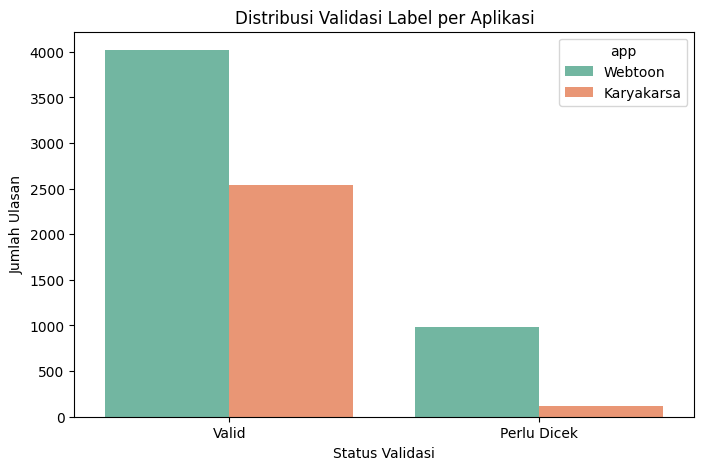

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='label_validasi', hue='app', data=df, palette='Set2')
plt.title('Distribusi Validasi Label per Aplikasi')
plt.xlabel('Status Validasi')
plt.ylabel('Jumlah Ulasan')
plt.show()

In [ ]:
!pip install wordcloud matplotlib
from wordcloud import WordCloud
import matplotlib.pyplot as plt

In [ ]:
def plot_wordcloud(data, title):
    text = ' '.join(data.dropna())
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

    plt.figure(figsize=(10,5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=16)
    plt.show()

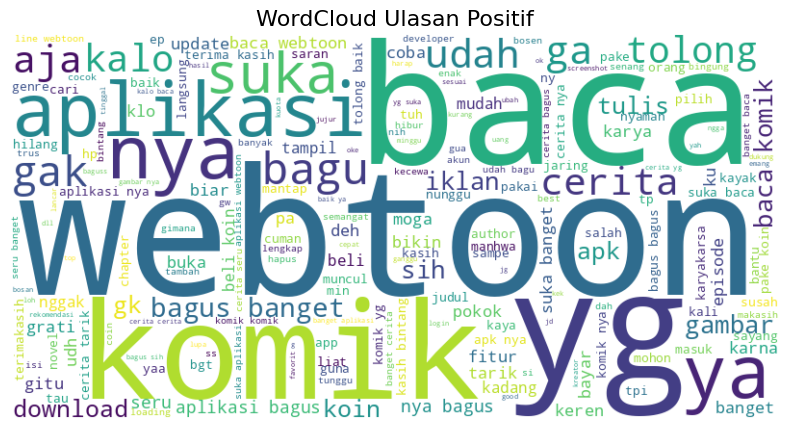

In [ ]:
# Positif
plot_wordcloud(df[df['sentimen'] == 'Positif']['ulasan_stem'], 'WordCloud Ulasan Positif')

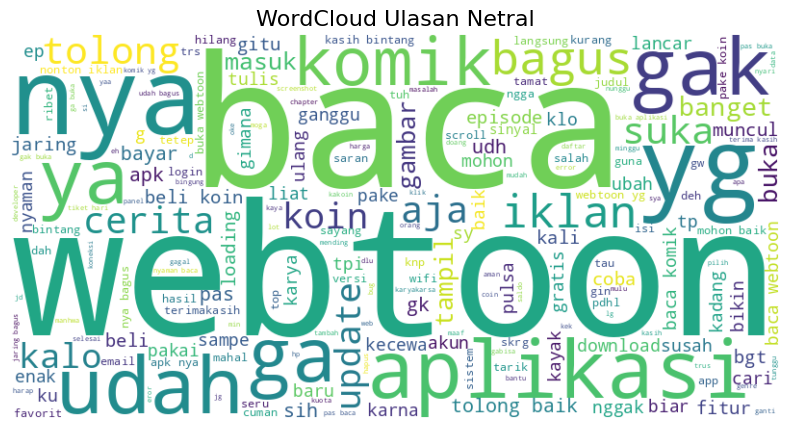

In [ ]:
# Netral
plot_wordcloud(df[df['sentimen'] == 'Netral']['ulasan_stem'], 'WordCloud Ulasan Netral')

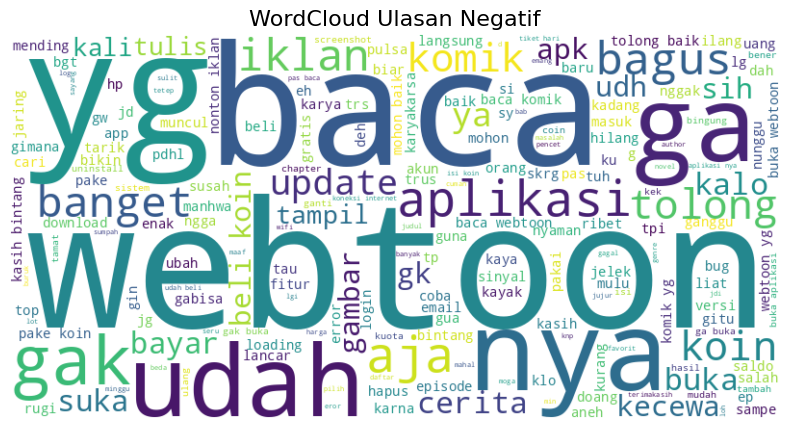

In [ ]:

# Negatif
plot_wordcloud(df[df['sentimen'] == 'Negatif']['ulasan_stem'], 'WordCloud Ulasan Negatif')

In [ ]:
import pandas as pd
import nltk
from nltk.util import ngrams
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

nltk.download('punkt')
nltk.download('punkt_tab') # Tambahkan ini untuk mengunduh sumber daya yang hilang

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
def get_top_bigrams(text_series, top_n=20):
    all_words = []
    for text in text_series.dropna():
        tokens = nltk.word_tokenize(text)
        all_words.extend(list(ngrams(tokens, 2)))  # buat bigram

    bigram_counts = Counter(all_words)
    return bigram_counts.most_common(top_n)

In [ ]:
def plot_bigrams(top_bigrams, title='Top Bigram'):
    labels = [' '.join(b) for b, _ in top_bigrams]
    freqs = [f for _, f in top_bigrams]

    plt.figure(figsize=(10,6))
    plt.barh(labels[::-1], freqs[::-1], color='skyblue')
    plt.title(title, fontsize=16)
    plt.xlabel('Frekuensi')
    plt.show()

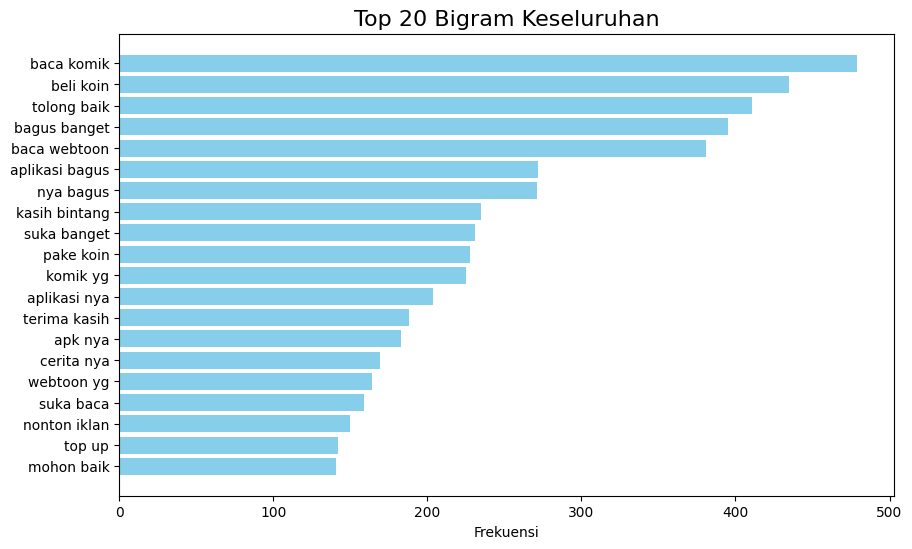

In [ ]:
top_bigrams_all = get_top_bigrams(df['ulasan_stem'], top_n=20)
plot_bigrams(top_bigrams_all, 'Top 20 Bigram Keseluruhan')

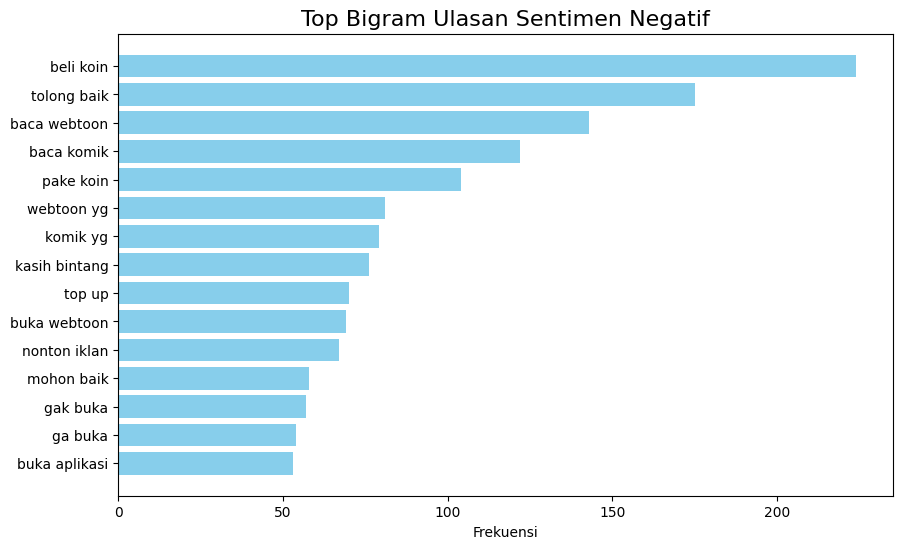

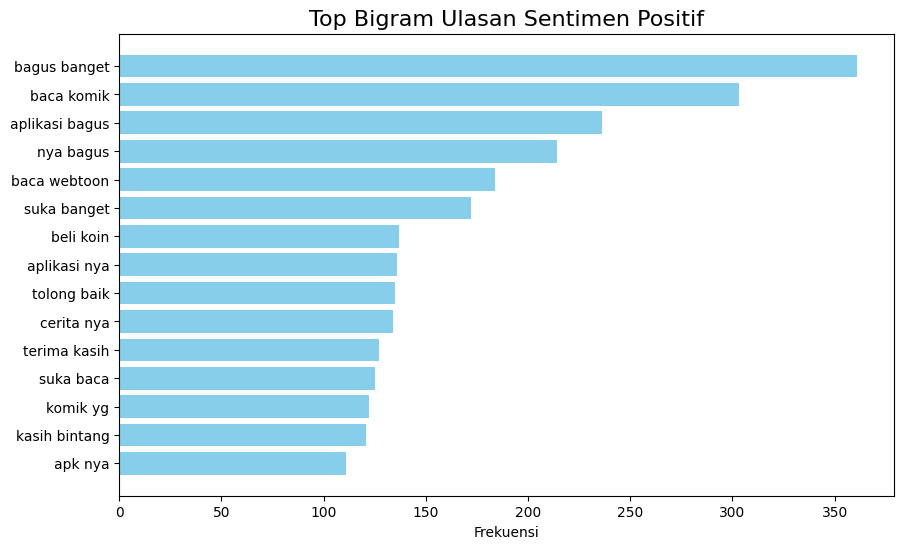

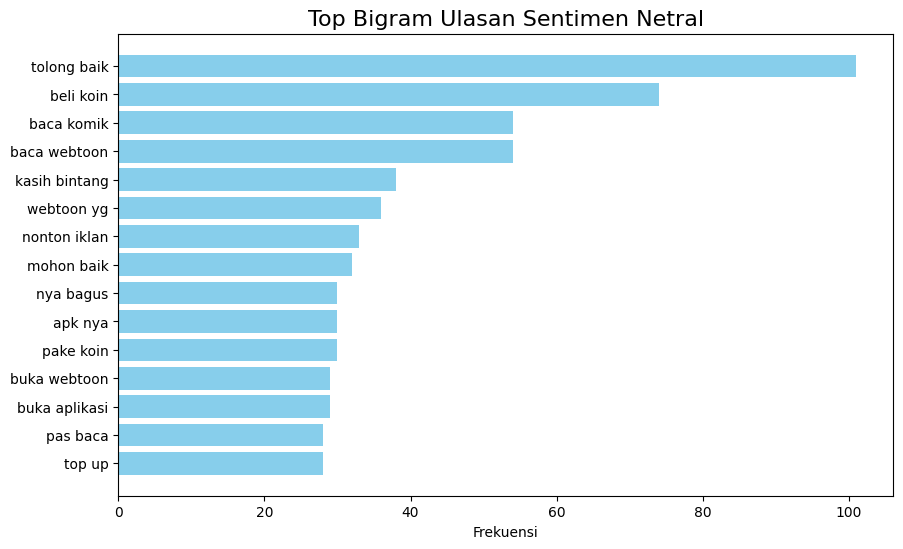

In [ ]:
sentimen_list = df['sentimen'].unique()

for s in sentimen_list:
    top_bigrams_sent = get_top_bigrams(df[df['sentimen']==s]['ulasan_stem'], top_n=15)
    plot_bigrams(top_bigrams_sent, f'Top Bigram Ulasan Sentimen {s}')

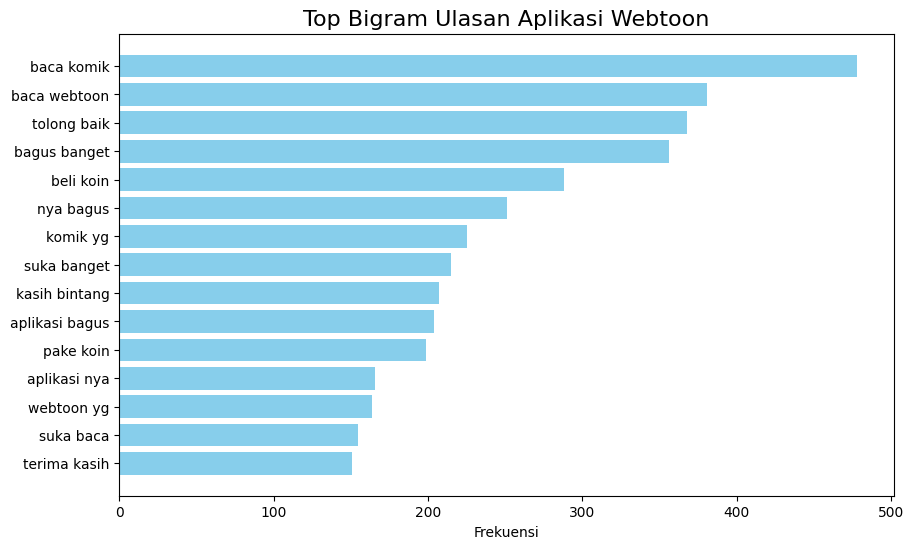

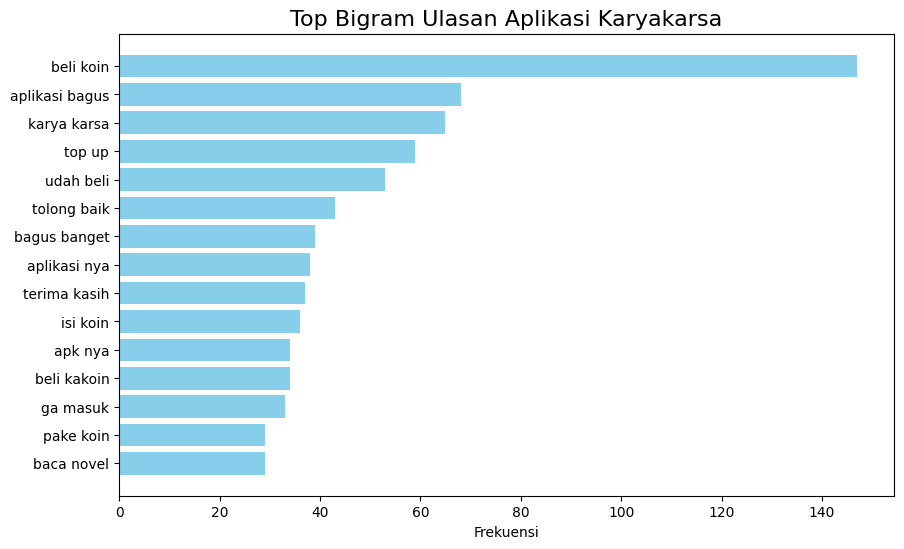

In [ ]:
apps = df['app'].unique()

for app in apps:
    top_bigrams_app = get_top_bigrams(df[df['app']==app]['ulasan_stem'], top_n=15)
    plot_bigrams(top_bigrams_app, f'Top Bigram Ulasan Aplikasi {app}')

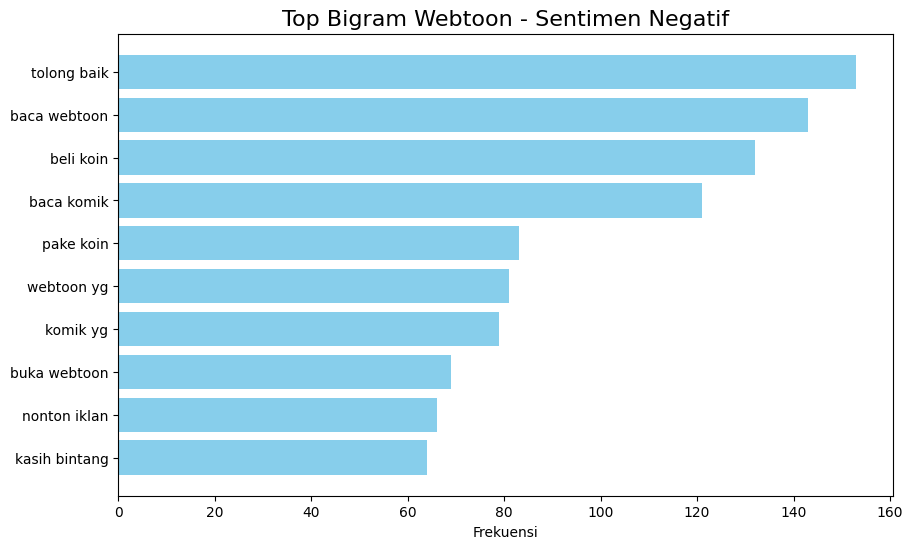

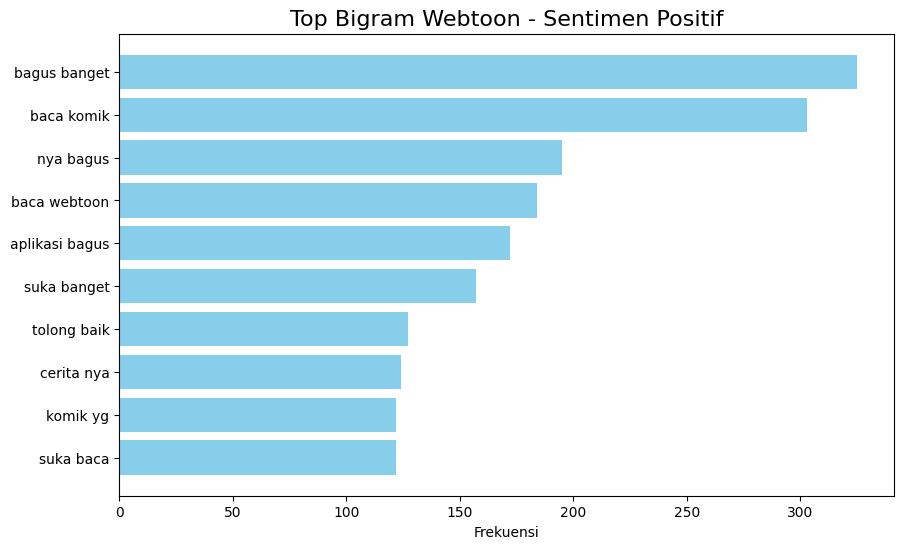

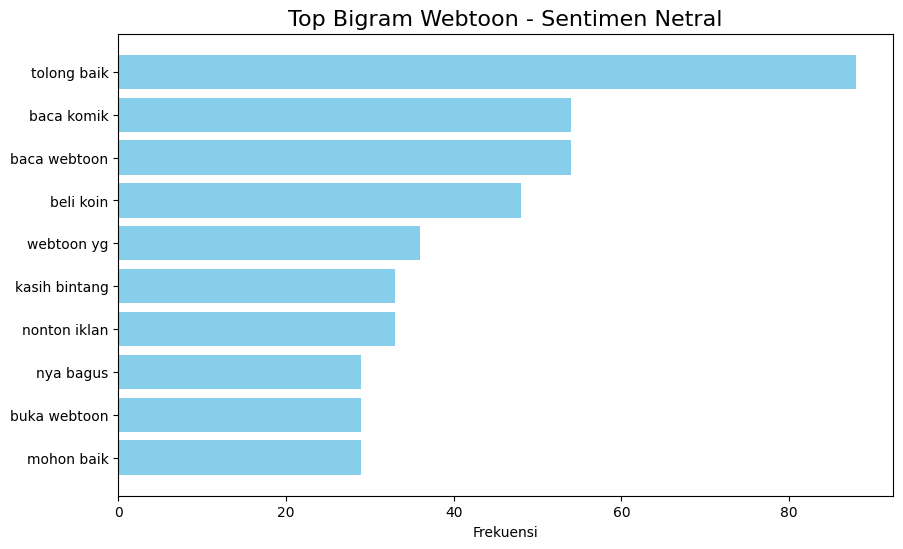

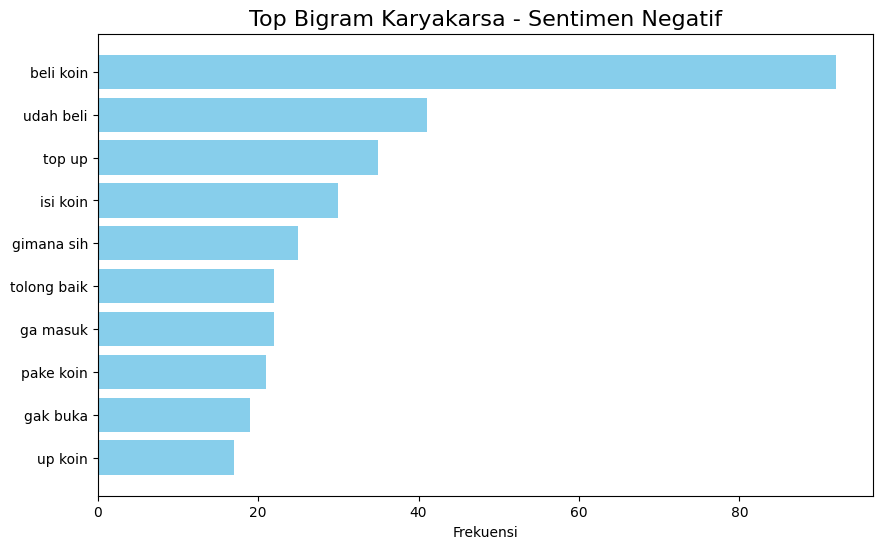

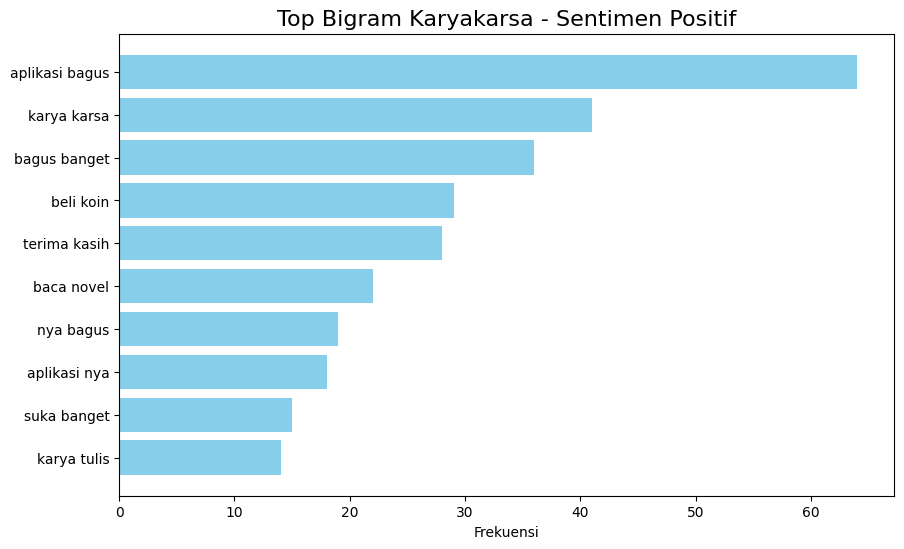

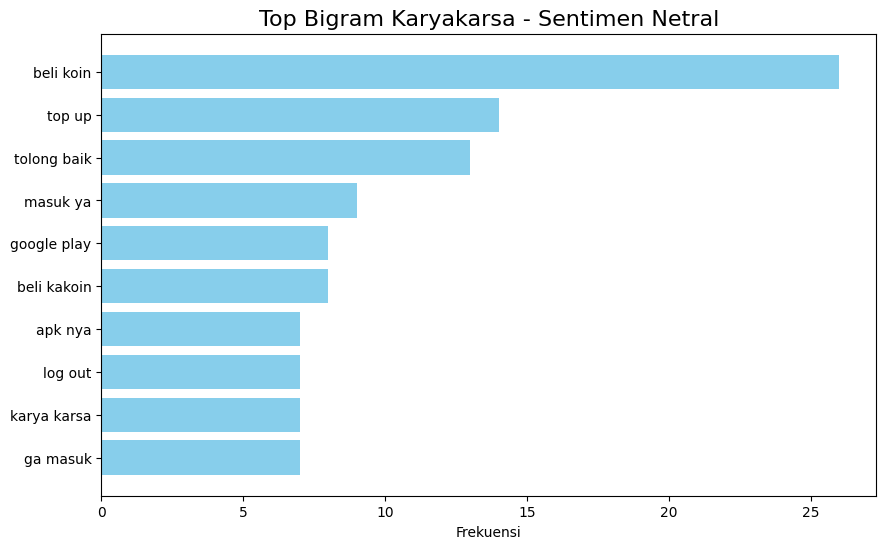

In [ ]:
for app in apps:
    for s in sentimen_list:
        subset = df[(df['app']==app) & (df['sentimen']==s)]
        if len(subset) > 0:
            top_bigrams_sub = get_top_bigrams(subset['ulasan_stem'], top_n=10)
            plot_bigrams(top_bigrams_sub, f'Top Bigram {app} - Sentimen {s}')

In [ ]:
def get_top_trigrams(text_series, top_n=20):
    all_words = []
    for text in text_series.dropna():
        tokens = nltk.word_tokenize(text)
        all_words.extend(list(ngrams(tokens, 3)))  # buat trigram

    trigram_counts = Counter(all_words)
    return trigram_counts.most_common(top_n)

In [ ]:
def plot_trigrams(top_trigrams, title='Top Trigram'):
    labels = [' '.join(t) for t, _ in top_trigrams]
    freqs = [f for _, f in top_trigrams]

    plt.figure(figsize=(10,6))
    plt.barh(labels[::-1], freqs[::-1], color='lightcoral')
    plt.title(title, fontsize=16)
    plt.xlabel('Frekuensi')
    plt.show()

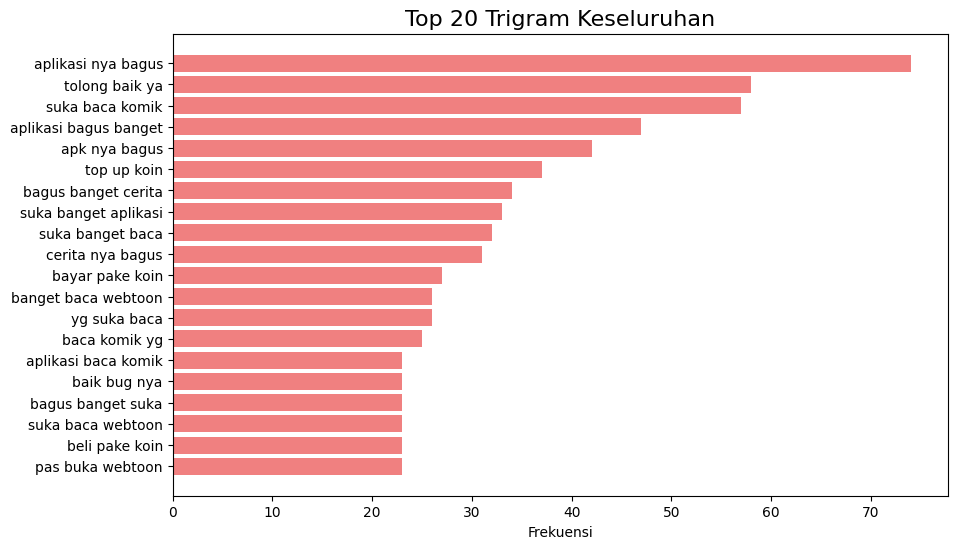

In [ ]:
top_trigrams_all = get_top_trigrams(df['ulasan_stem'], top_n=20)
plot_trigrams(top_trigrams_all, 'Top 20 Trigram Keseluruhan')

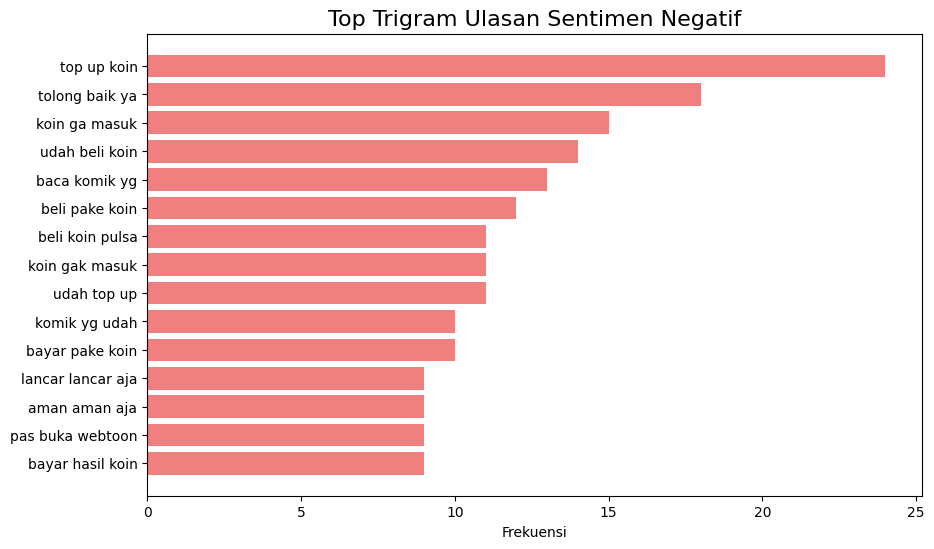

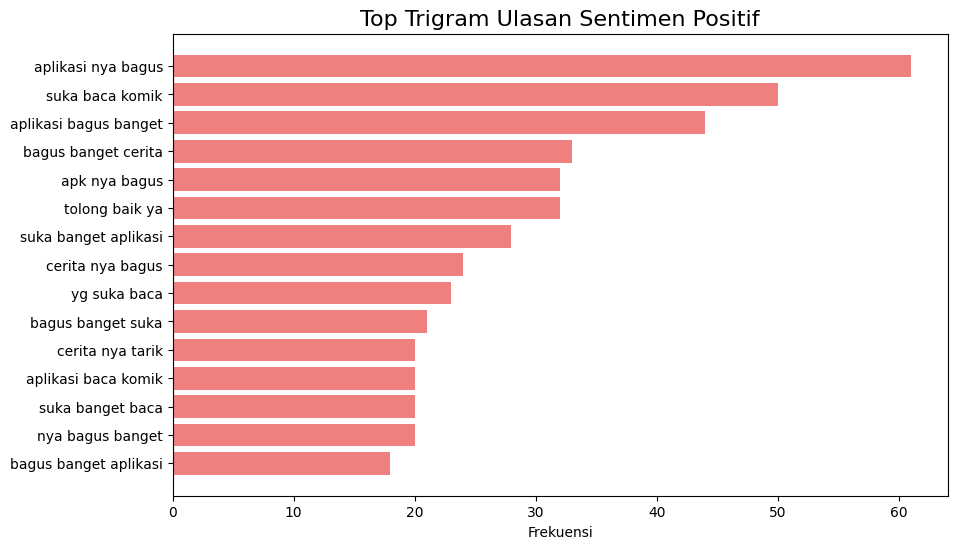

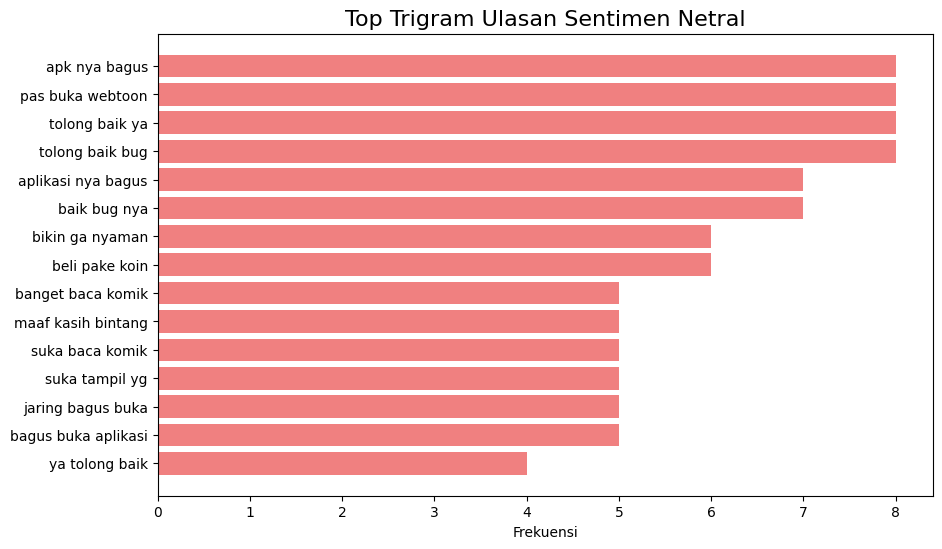

In [ ]:
sentimen_list = df['sentimen'].unique()

for s in sentimen_list:
    top_trigrams_sent = get_top_trigrams(df[df['sentimen']==s]['ulasan_stem'], top_n=15)
    plot_trigrams(top_trigrams_sent, f'Top Trigram Ulasan Sentimen {s}')

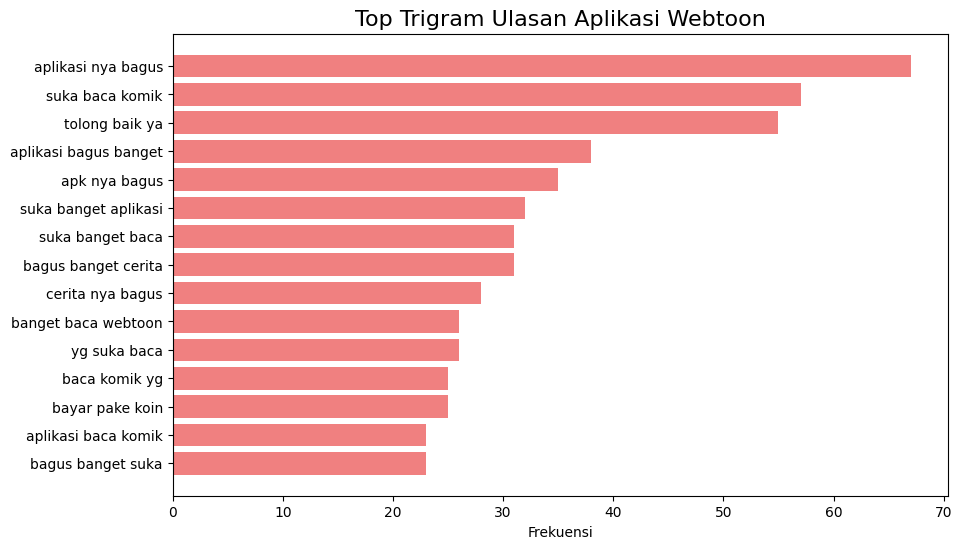

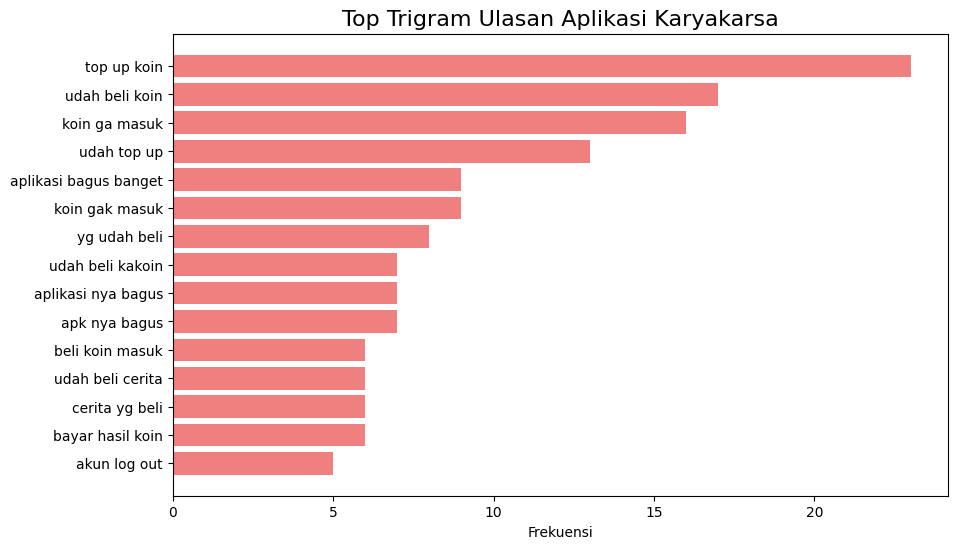

In [ ]:
apps = df['app'].unique()

for app in apps:
    top_trigrams_app = get_top_trigrams(df[df['app']==app]['ulasan_stem'], top_n=15)
    plot_trigrams(top_trigrams_app, f'Top Trigram Ulasan Aplikasi {app}')

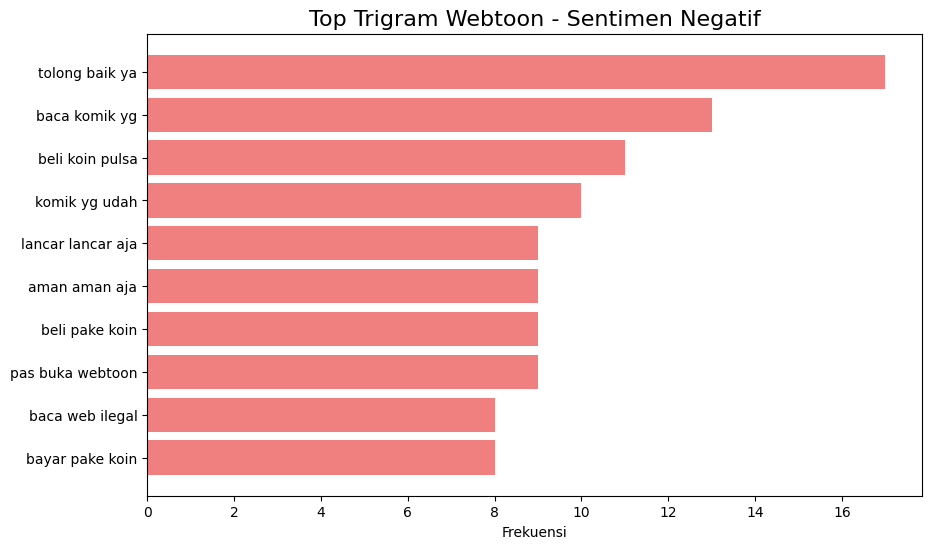

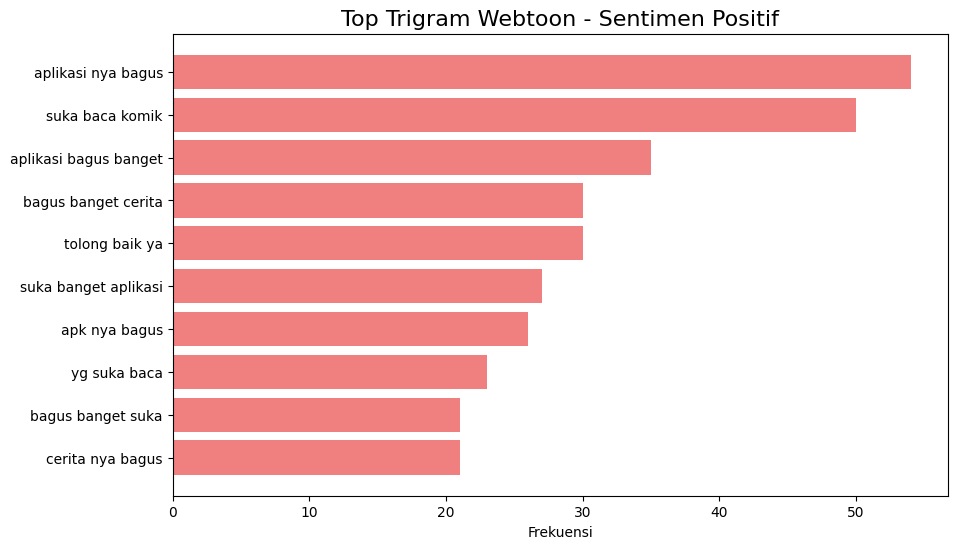

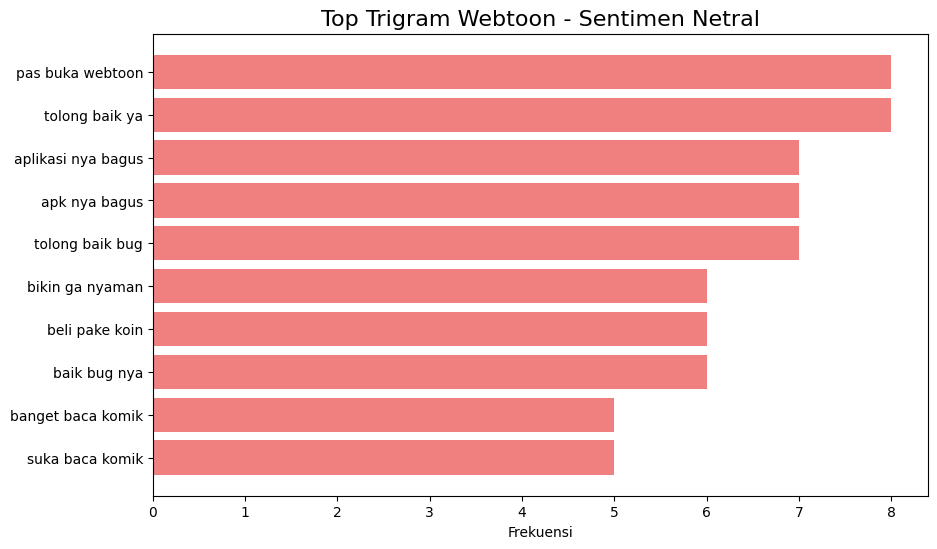

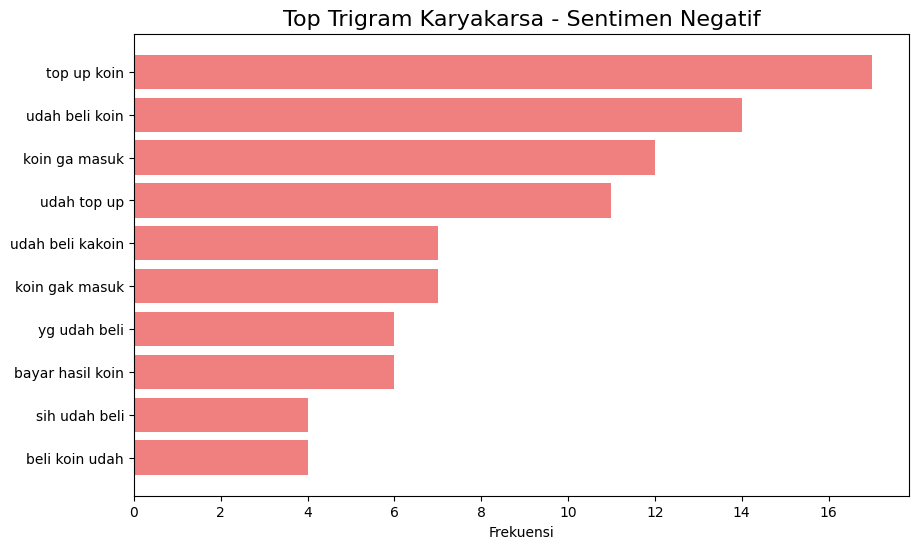

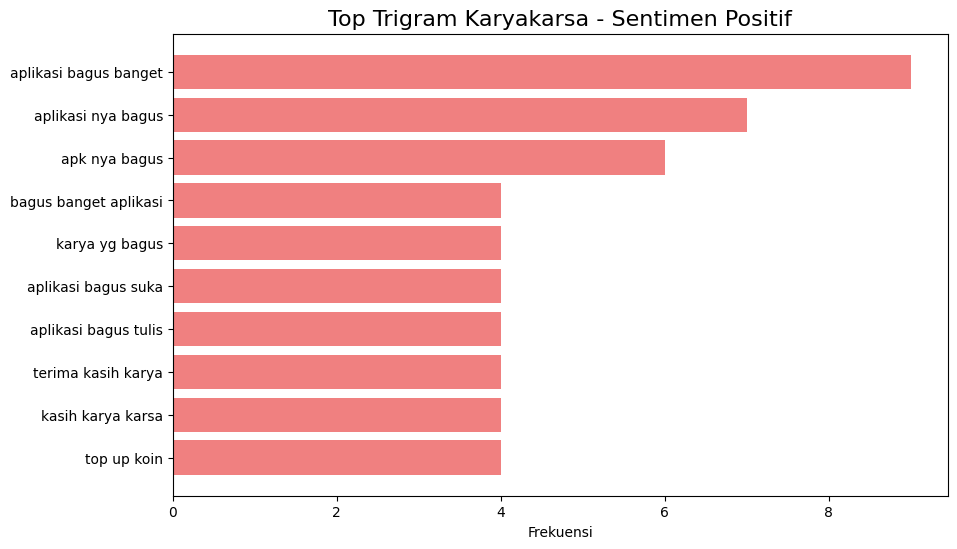

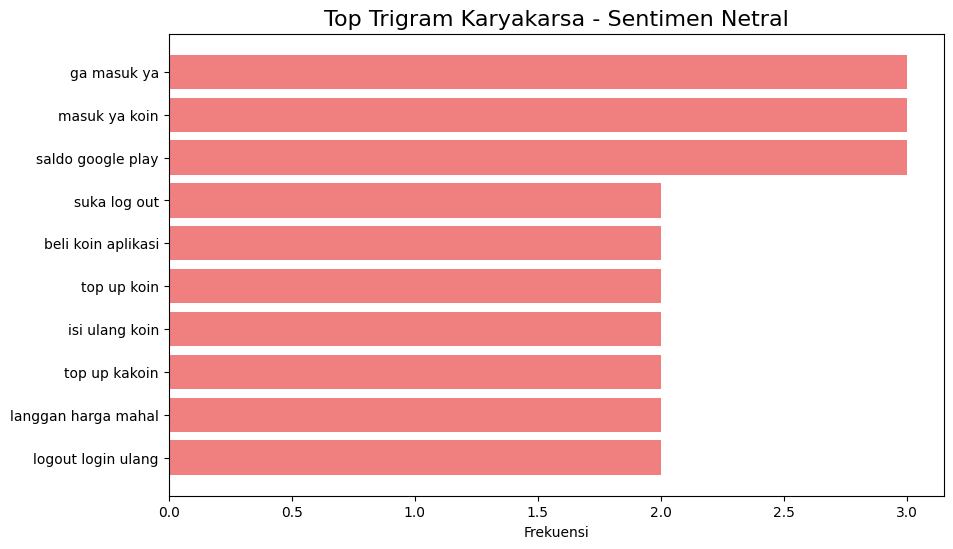

In [ ]:
for app in apps:
    for s in sentimen_list:
        subset = df[(df['app']==app) & (df['sentimen']==s)]
        if len(subset) > 0:
            top_trigrams_sub = get_top_trigrams(subset['ulasan_stem'], top_n=10)
            plot_trigrams(top_trigrams_sub, f'Top Trigram {app} - Sentimen {s}')